# Step 1: 建立可視化資料 (Data Generation)

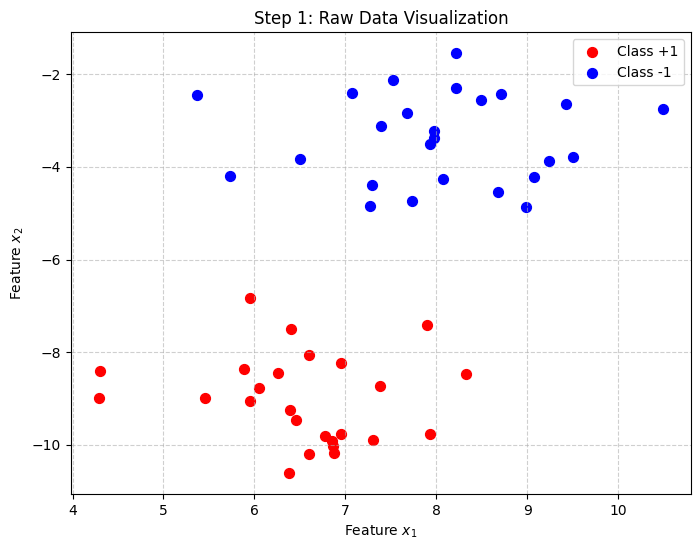

資料維度 X shape: (50, 2)
前 5 筆標籤 y: [ 1 -1  1 -1 -1]


In [6]:
# --- Cell 1: 建立並可視化資料 ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. 產生模擬數據
# n_samples=50: 50個點
# centers=2: 分成兩群
# random_state=6: 固定亂數種子，保證每次結果一樣
X, y = make_blobs(n_samples=50, centers=2, random_state=6)

# 將標籤 0 改為 -1，以符合 SVM 數學推導習慣 (y belong to {1, -1})
y = np.where(y == 0, -1, 1)

# 2. 可視化原始數據
plt.figure(figsize=(8, 6))
# 畫出類別 1 (紅色)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class +1', s=50)
# 畫出類別 -1 (藍色)
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='blue', label='Class -1', s=50)

plt.title("Step 1: Raw Data Visualization")
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"資料維度 X shape: {X.shape}")
print(f"前 5 筆標籤 y: {y[:5]}")

# Step 2: 訓練模型並找到支持向量 (Find Support Vectors)

SVM 訓練完成！
總共有 3 個支持向量 (Support Vectors)


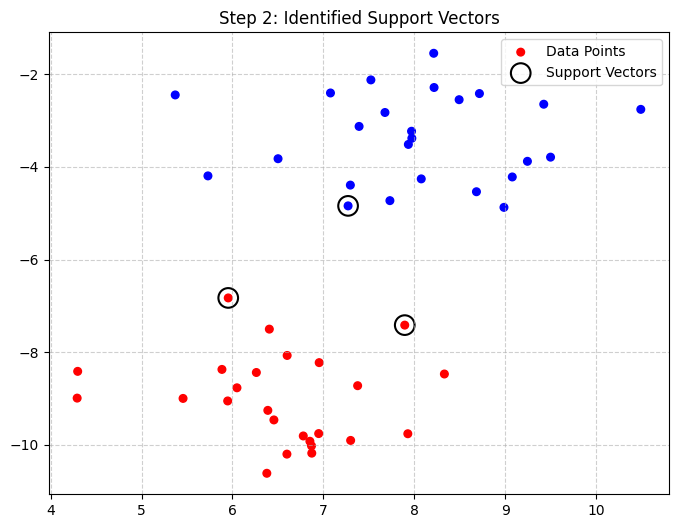

支持向量的座標 (前3個):
[[ 7.27059007 -4.84225716]
 [ 5.95313618 -6.82945967]
 [ 7.89359985 -7.41655113]]


In [7]:
# --- Cell 2: 訓練 SVM 並找出支持向量 ---
from sklearn.svm import SVC

# 1. 建立模型 (使用線性核 Linear Kernel)
# C是一個很大的數，代表 Hard Margin (不允許錯誤分類)
model = SVC(kernel='linear', C=1000)
model.fit(X, y)

# 2. 獲取支持向量資訊
support_vectors = model.support_vectors_
support_vector_indices = model.support_ # 支持向量在原始資料 X 中的索引

print("="*30)
print("SVM 訓練完成！")
print(f"總共有 {len(support_vectors)} 個支持向量 (Support Vectors)")
print("="*30)

# 3. 可視化：標記出哪些點是支持向量
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=30, label='Data Points')

# 用黑色圓圈圈出支持向量
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            s=200, linewidth=1.5, facecolors='none', edgecolors='k',
            label='Support Vectors')

plt.title("Step 2: Identified Support Vectors")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("支持向量的座標 (前3個):")
print(support_vectors[:3])

# Step 3: 代入公式求解與驗證 (Formula Verification)

In [8]:
# --- Cell 3: 數學公式驗證 (Finding w and b) ---

# 1. 從 Sklearn 模型直接取得 w 和 b
w_sklearn = model.coef_[0]
b_sklearn = model.intercept_[0]

print(f"[Sklearn Result] w: {w_sklearn}")
print(f"[Sklearn Result] b: {b_sklearn}")
print("-" * 50)

# 2. 手動利用公式驗證 w
# 公式: w = sum(alpha_i * y_i * x_i)
# model.dual_coef_ 儲存的是 (alpha_i * y_i) 的值，僅針對支持向量
dual_coef = model.dual_coef_[0] # 這就是 alpha * y
sv_matrix = model.support_vectors_

# 矩陣乘法計算 w: (1, n_sv) dot (n_sv, 2) -> (1, 2)
w_manual = np.dot(dual_coef, sv_matrix)

print(f"[Manual Calculation] w = sum(alpha_i * y_i * x_i)")
print(f"計算結果 w: {w_manual}")

# 3. 驗證兩者是否相同
# np.allclose 用來比較浮點數是否足夠接近
if np.allclose(w_sklearn, w_manual):
    print("\n>>> 驗證成功！數學推導公式與程式實作結果一致！ <<<")
else:
    print("\n>>> 驗證失敗，請檢查公式。 <<<")

# 4. 手動驗證 b (選第一個支持向量來算)
# 公式: b = y_k - w * x_k
sv_sample = sv_matrix[0] # 取第一個 SV
y_sample = y[support_vector_indices[0]] # 取該 SV 對應的標籤
b_manual = y_sample - np.dot(w_manual, sv_sample)

print(f"\n[Manual Calculation] b (based on 1st SV): {b_manual:.4f}")
print(f"(注意：Sklearn 的 b 通常是所有支持向量計算出的 b 的平均值，所以可能會有微小誤差)")

[Sklearn Result] w: [-0.25395113 -0.83807751]
[Sklearn Result] b: -3.211559897362612
--------------------------------------------------
[Manual Calculation] w = sum(alpha_i * y_i * x_i)
計算結果 w: [-0.25395113 -0.83807751]

>>> 驗證成功！數學推導公式與程式實作結果一致！ <<<

[Manual Calculation] b (based on 1st SV): -3.2118
(注意：Sklearn 的 b 通常是所有支持向量計算出的 b 的平均值，所以可能會有微小誤差)


# Step 4: 最終呈現分割樣子 (Final Visualization)

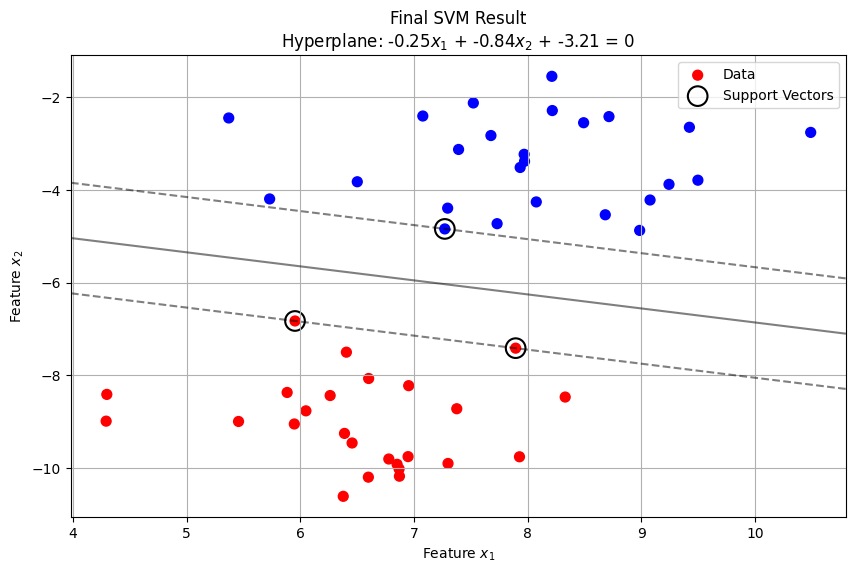

In [9]:
# --- Cell 4: 最終可視化 (Decision Boundary & Margins) ---

def plot_svm_boundary(model, X, y):
    plt.figure(figsize=(10, 6))

    # 1. 繪製數據點
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr', label='Data')

    # 2. 建立網格 (Meshgrid) 來繪製等高線
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # 計算每個網格點到超平面的距離 (Decision Function)
    Z = model.decision_function(xy).reshape(XX.shape)

    # 3. 繪製等高線 (Contour)
    # Z=0 是超平面 (實線)
    # Z=1 和 Z=-1 是邊界 (虛線)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # 4. 再次圈出支持向量
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=200,
               linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')

    # 標示方程式
    w = model.coef_[0]
    b = model.intercept_[0]
    plt.title(f"Final SVM Result\nHyperplane: {w[0]:.2f}$x_1$ + {w[1]:.2f}$x_2$ + {b:.2f} = 0")
    plt.xlabel("Feature $x_1$")
    plt.ylabel("Feature $x_2$")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# 執行繪圖函數
plot_svm_boundary(model, X, y)